In [2]:
from sklearn.preprocessing import MinMaxScaler
import time
from pandas import value_counts
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.linear_model import Perceptron
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
from lazypredict.Supervised import LazyClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree           
from IPython.display import Image, display              
import pydotplus    
data = pd.read_excel(
    r"/home/arshia/arshia/Msc/Air Tehran/Orginal Air Quality Tehran.xlsx")
data.drop('Time',axis=1,inplace=True)
def probThreshold(inpProb):
    if inpProb  <  51:
        return(0)
    if 50<inpProb < 101:
        return(1)
    if 100<inpProb<151:
        return(2)
    if 150<inpProb<201:
        return(3)
    if 200<inpProb<301:
        return(4)
    else:
        return(5)
          
data['Outcomes']=data['AQI'].apply(probThreshold)

In [8]:
X=data.iloc[:,:-2].values
y=data.iloc[:,-1].values
unique,counts=np.unique(y,return_counts=True)
print("TrainSet (class: count) = ", dict(zip(unique, counts)), "TrainSize : ", y.shape[0])
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=.15, random_state =12)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.176, random_state=12) #0.176 * 0.85 = 0.15

unique, counts = np.unique(y_train, return_counts=True)
print("TrainSet (class: count) = ", dict(zip(unique, counts)), "TrainSize : ", y_train.shape[0])

unique, counts = np.unique(y_test, return_counts=True)
print("TestSet (class: count) =", dict(zip(unique, counts)), "TestSize : ", y_test.shape[0])

unique, counts = np.unique(y_val, return_counts=True)
print("ValSet (class: count) = ", dict(zip(unique, counts)), "ValSize : ", y_val.shape[0])

print(y.shape[0], " = ", (y_train.shape[0] + y_test.shape[0] + y_val.shape[0]))

TrainSet (class: count) =  {0: 79, 1: 1196, 2: 487, 3: 61, 4: 2, 5: 2} TrainSize :  1827
TrainSet (class: count) =  {0: 54, 1: 835, 2: 339, 3: 48, 4: 1, 5: 1} TrainSize :  1278
TestSet (class: count) = {0: 12, 1: 185, 2: 70, 3: 7, 5: 1} TestSize :  275
ValSet (class: count) =  {0: 13, 1: 176, 2: 78, 3: 6, 4: 1} ValSize :  274
1827  =  1827


In [4]:
clf = RandomForestClassifier()
start = time.time()
models=clf.fit(X_train,y_train)
stop = time.time()
print(f"Training time: {stop - start}s")
prediction=models.predict(X_test)

Training time: 0.493804931640625s


0.9890909090909091
0.7428571428571429
0.7624708624708625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00       185
           2       0.96      1.00      0.98        70
           3       1.00      0.71      0.83         7
           5       0.00      0.00      0.00         1

    accuracy                           0.99       275
   macro avg       0.79      0.74      0.76       275
weighted avg       0.99      0.99      0.99       275



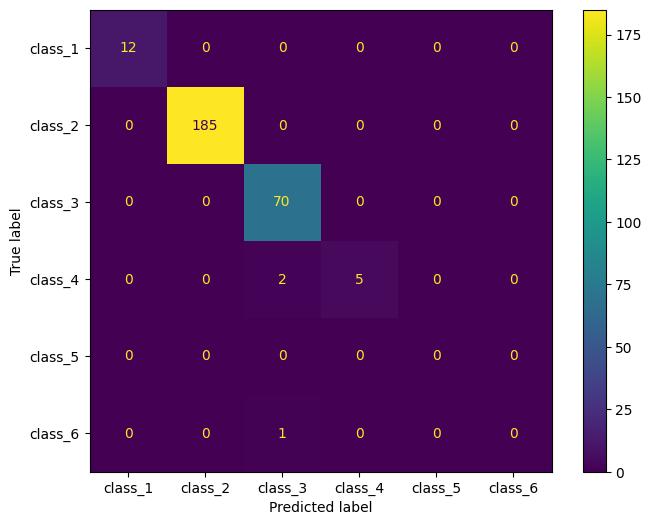

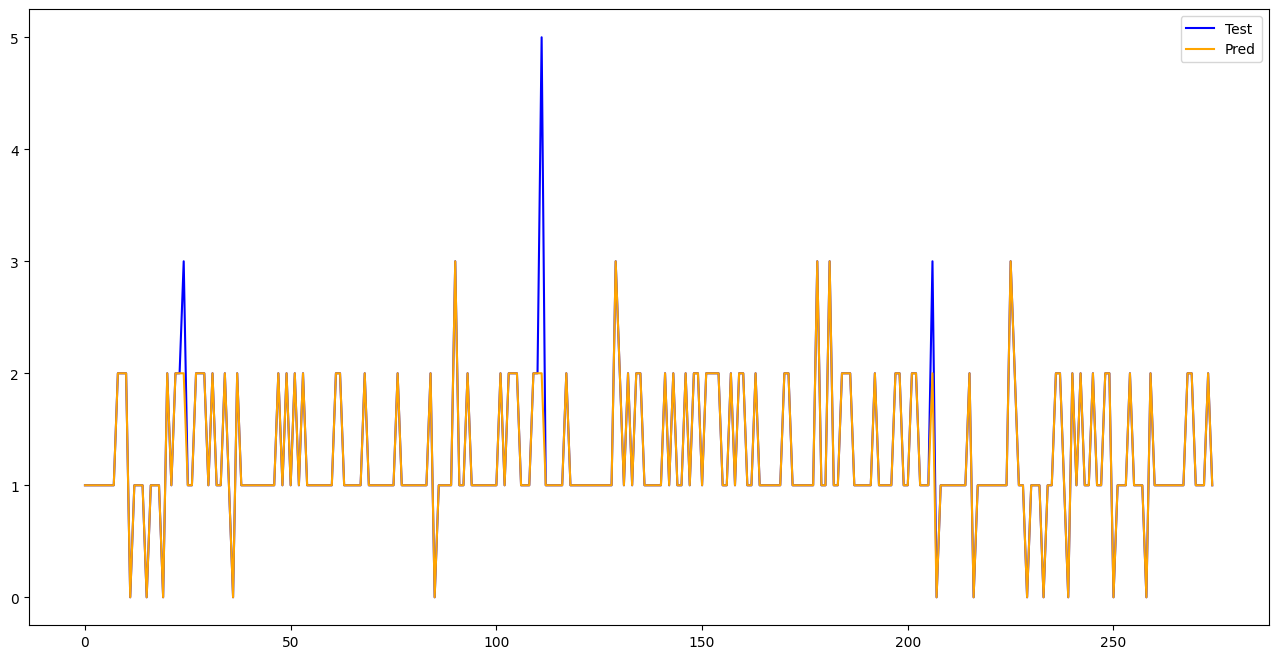

In [11]:
print(accuracy_score(y_test,prediction))
print(balanced_accuracy_score(y_test,prediction))
print(f1_score(y_test,prediction,average='macro'))
print(classification_report(y_test, prediction)) 
fig, ax = plt.subplots(figsize=(8, 6))  
cm=confusion_matrix(y_test, prediction,labels=clf.classes_)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"])
cmp.plot(ax=ax)       
plt.show()
plt.figure(figsize=(16,8))
plt.plot(y_test, color='blue', label='Test')
plt.plot(prediction, color='orange', label='Pred')
plt.legend()
plt.show()